In [1]:
source("../src/00_init.R")

Warning message:
“package ‘dplyr’ was built under R version 4.3.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:data.table’:

    between, first, last


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine


Warning message:
“package ‘stringr’ was built under R version 4.3.2”


In [2]:
library(patchwork)
library(pheatmap)

In [3]:
library(preprocessCore)
library(gridExtra)

In [4]:
outpath = "your_path_here"

In [5]:
dir.create(outpath)

Warning message in dir.create(outpath):
“'../processed_data/HUMAN/human_bike_comparison' already exists”


In [62]:
dir.create(file.path(outpath, "limma_paired"))

Warning message in dir.create(file.path(outpath, "limma_paired")):
“'../processed_data/HUMAN/human_bike_comparison/limma_paired' already exists”


In [63]:
col_annot_df$tissue <- as.factor(col_annot_df$tissue)

In [64]:
design <- model.matrix(~ 0+ col_annot_df$tissue + col_annot_df$sampleId)
#colnames(design) <- levels(col_annot_df$tissue)

In [65]:
colnames(design) <- gsub("\\$", "", gsub("col_annot_df", "", colnames(design)))

In [66]:
fit <- lmFit(full_array_val, design)

In [67]:
fit <- eBayes(fit)

In [68]:
contrast.matrix <- makeContrasts(Diff=tissueplaque-tissueplasma, levels=design)

In [69]:
fit2 <- contrasts.fit(fit, contrast.matrix)
fit2 <- eBayes(fit2)

In [70]:
results <- topTable(fit2, adjust="fdr", sort.by="B", number=Inf)

In [71]:
my_wt(results, file.path(outpath, "limma_paired", "DE_results.tsv"), ROWNAMES = TRUE)

Warning message:
“ggrepel: 68 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


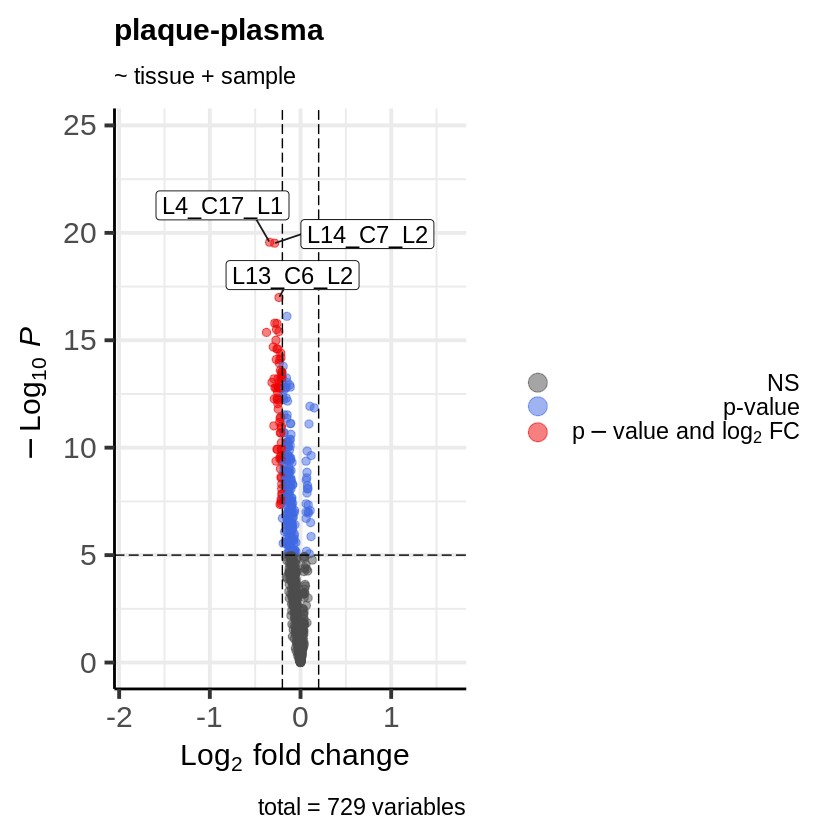

In [72]:
EnhancedVolcano(results, x = "logFC", y = "adj.P.Val", 
                lab = rownames(results), 
                FCcutoff = 0.2, 
                legendPosition = "right",
                title = "plaque-plasma",
                subtitle = "~ tissue + sample",
                boxedLabels = TRUE, drawConnectors = TRUE, arrowheads = FALSE)

In [73]:
ggsave(file.path(outpath, "limma_paired", "volcano.png"), width = 10, height = 6)

Warning message:
“ggrepel: 68 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


In [74]:
for(logTHR in c(0.2, 0.3)){
topHits <- row.names(results[abs(results$logFC) > logTHR & results$adj.P.Val < 0.05,])
pheatmap(full_array_val[topHits,], 
         annotation_col = col_annot_df,
        fontsize = 5,
         cluster_col = FALSE,
         width = 12,
         height = max(round(length(topHits)/8), 3),
         filename = file.path(outpath,"limma_paired", paste0("hm_both_tissues_", gsub("\\.", "", as.character(logTHR)), ".pdf"))
        )
    }

## across-tissue normalisation

In [24]:
array_aorta <- fread("your_path_to_data_aorta/full_samples_combined.csv")

In [25]:
array_aorta$coordinate_unique <- paste0(array_aorta$Coordinate, "_", array_aorta$library)

In [27]:
array_plasma <- fread("your_path_to_data_plasma/full_samples_combined.csv")

In [28]:
array_plasma$coordinate_unique <- paste0(array_plasma$Coordinate, "_", array_plasma$library)

In [26]:
annot_aorta <- fread("your_path/metadata/human_bike_cohort_plaque_aorta.tsv")
annot_plasma <- fread("your_path/metadata/human_bike_cohort_plasma.tsv")

In [29]:
array_full <- rbind(array_plasma, array_aorta)`

In [ ]:
annot <- rbind(annot_plasma, annot_aorta)
annot <- annot[sample_name %in% unique(array_full$sample_name),]

In [32]:
full_array <- array_full %>% select(coordinate_unique, avrg, sample_name ) %>%
    pivot_wider(names_from = sample_name, values_from = avrg)

In [33]:
full_array <- as.data.frame(full_array)
head(full_array)

,coordinate_unique,284,344,371,417,437,457,460,464,466,⋯,plaque_525,plaque_526,plaque_527,plaque_528,plaque_529,plaque_530,plaque_531,plaque_589,plaque_602,plaque_603
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,L1_C1_L1,0.1918302,0.2925801,0.25048670,0.12338630,0.2737094,0.2152177,0.09173748,0.10884260,0.1349341,⋯,0.1525584,0.13748560,0.17218136,0.56991173,0.08644161,0.3409254,0.1252465,0.1110399,0.2173072,0.14519403
2,L2_C1_L1,0.1202419,0.0755195,0.12325276,0.33161673,0.3116549,0.1853617,0.08280303,0.06724975,0.2045876,⋯,0.1099546,0.05516064,0.09391144,0.05551354,0.05311774,0.1208387,0.1239408,0.1528572,0.1846018,0.09430330
3,L3_C1_L1,0.1036008,0.1804619,0.08054601,0.07733496,0.4675840,0.3229423,0.04181636,0.88079215,0.2896442,⋯,0.2184367,0.15260828,0.15821487,0.19412112,0.09803758,0.1184386,0.3969789,0.2351453,0.5144435,0.12115187
4,L4_C1_L1,0.2476820,0.3490018,0.12788387,0.22459396,0.6495960,0.6552024,0.12577051,0.48357955,0.5317130,⋯,0.1970995,0.10346734,0.16574112,0.29722643,0.09366007,0.1617548,0.3477351,0.3016414,0.3928115,0.13606726
5,L5_C1_L1,0.3229387,0.1346114,0.15692333,0.29432787,0.3320298,0.3378427,0.14353627,0.11303975,0.2232326,⋯,0.1160217,0.06225049,0.10663443,0.09067902,0.06129783,0.3237567,0.1705620,0.1840153,0.2477735,0.08615046
6,L6_C1_L1,0.6051033,0.8267120,0.28384126,0.64393538,0.5873033,0.4686875,0.19984354,0.32796197,0.6886649,⋯,0.2910025,0.82032703,0.20061640,0.31377473,0.09417584,0.1831001,0.3818224,0.3412511,0.6485608,0.17960615


In [34]:
row.names(full_array) <- full_array$coordinate_unique

In [ ]:
samples_plasma <- unique(array_plasma$sample_name)
samples_aorta <- unique(array_aorta$sample_name)

samples <- intersect(samples_plasma, gsub("plaque_", "", samples_aorta))
samples <- c(samples,paste0("plaque_",samples))

In [21]:
full_array <- full_array[, samples]

In [22]:
dir.create(file.path(outpath, "norm_across_tissues"))

Warning message in dir.create(file.path(outpath, "norm_across_tissues")):
“'../processed_data/HUMAN/human_bike_comparison/norm_across_tissues' already exists”


In [23]:
full_array_QN <- normalize.quantiles(as.matrix(full_array))

In [ ]:
colnames(full_array_QN) <- colnames(full_array)
row.names(full_array_QN) <- row.names(full_array)

In [ ]:
annot <- as.data.frame(annot)
row.names(annot) <- annot$sample_name
annot <- annot[-1]

In [30]:
pheatmap(full_array_QN, 
         annotation_col = annot,
        fontsize_row = 2,
         width = 10,
         height = 20,
        filename = file.path(outpath, "norm_across_tissues", "hm_both_tissues.pdf"))

In [32]:
write.csv(full_array_QN, file.path(outpath, "norm_across_tissues", "QN_both_tissues.csv"), quote = FALSE)